In [2]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

from sv3.nn import FunctionalModelJac, MLP
from sv3.svd_sgd import SVDOptimizer

import sys
sys.path.append('..')
import copy

from experiments.experiment_code.experiment_utils import train_loop_standard, train_loop_svd, set_seed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### Define dataset

In [44]:
SEED = 2184
set_seed(SEED)

D = 128
noise_std = 0.1
Ntrain = 10_000
Nval = 1_000
w = torch.randn(1,D)

xtrain = torch.randn(Ntrain, D)
xval = torch.randn(Nval, D)
ytrain = F.linear(xtrain,w) + noise_std * torch.randn(xtrain.shape[0],1)
yval = F.linear(xval,w) + noise_std * torch.randn(xval.shape[0],1)

train_dataset = TensorDataset(xtrain, ytrain)
val_dataset = TensorDataset(xval, yval)


### Define model

In [45]:
SEED = 437438
set_seed(SEED)
model_base = nn.Linear(D, 1, bias=False).to(device)
init_state = copy.deepcopy(model_base.state_dict())
del model_base # free memory

### Define params

In [50]:
LOADER_SEED = 12345
batch_size = 64
n_epoch = 100

### Train Adam

In [54]:
model_adam = nn.Linear(D, 1, bias=False).to(device)
model_adam.load_state_dict(init_state)
model_adam = model_adam.to(device)

LR_ADAM = 1e-2

optimizer = torch.optim.Adam(model_adam.parameters(), lr=LR_ADAM)
def loss_fn(pred,y):
    return (pred-y).pow(2).mean()

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

model_adam, losses_adam = train_loop_standard(model_adam, optimizer, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=True)

Using device cpu


100%|██████████| 100/100 [00:03<00:00, 30.01it/s]


### Train Sven

In [57]:
model_svd = nn.Linear(D, 1, bias=False).to(device)
model_svd.load_state_dict(init_state)
model_svd = model_svd.to(device)

def loss_fn(pred,y):
    return (pred-y).pow(2).sum(dim=1)

LR_SVD = 0.5
RTOL = 1e-3
K = 4


model_svd = FunctionalModelJac(model_svd, loss_fn, device=device)
optimizer = SVDOptimizer(model_svd,lr=LR_SVD,k=K,rtol=RTOL,track_svd_info=True,svd_mode='randomized', use_rmsprop=False)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

model_svd, losses_svd, optimizer = train_loop_svd(model_svd,optimizer,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
svd_info = optimizer.svd_info

torch.compiler.reset()

100%|██████████| 100/100 [00:09<00:00, 10.42it/s]


### Compare

(0.0, 20.0)

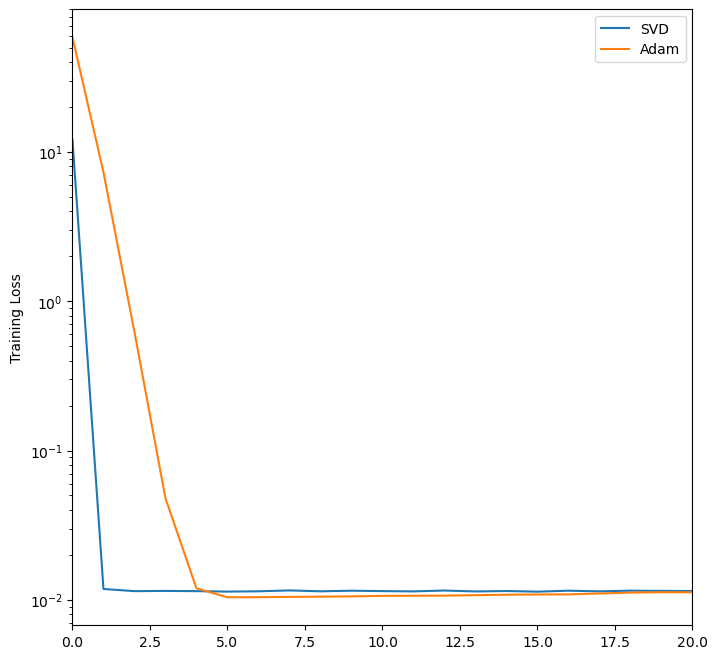

In [58]:
plt.figure(figsize=(8,8))
plt.plot(losses_svd['train'],label='SVD')
plt.plot(losses_adam['train'],label='Adam')
plt.legend()
plt.ylabel("Training Loss")
plt.yscale('log')
plt.xlim([0,20])

### Look at the Hessian

In [ ]:
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from torch.func import functional_call, hessian

model_init = nn.Linear(D, 1, bias=False).to(device)

model_init.load_state_dict(init_state)
model_init = model_init.to(device)
param_name_shape_sizes = []
for name, param in model_init.named_parameters():
    param_name_shape_sizes.append((name, param.shape, param.numel()))

params_init = parameters_to_vector(model_init.parameters())  # (D,)

def loss_for_hessian(params_flat, X, Y):
    p = {}
    i = 0
    for (name, shape, size) in param_name_shape_sizes:
        p[name] = params_flat[i:i+size].view(shape)
        i += size
    pred = functional_call(model_init, p, X)
    loss = (pred - Y).pow(2).sum(dim=1).mean()
    return loss

H = hessian(loss_for_hessian)(params_init, xtrain, ytrain).detach()

In [73]:
eigvals, eigvecs = torch.linalg.eigh(H)

Text(0, 0.5, 'Eigenvalue')

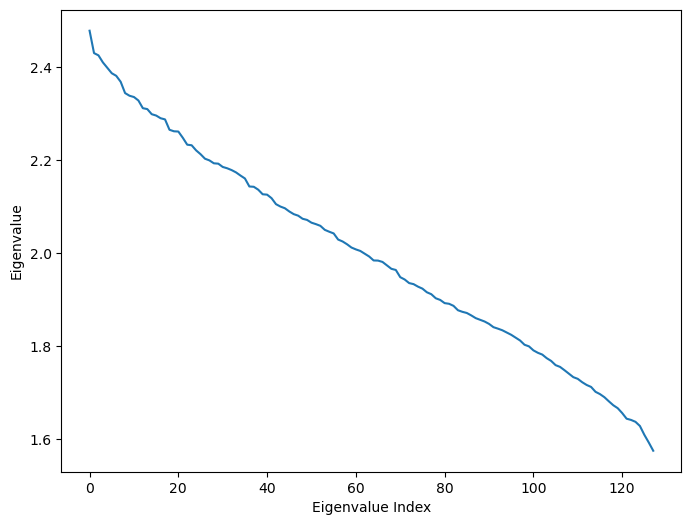

In [83]:
plt.figure(figsize=(8,6))
plt.plot(eigvals.numpy()[::-1])
plt.xlabel("Eigenvalue Index")
plt.ylabel("Eigenvalue")

### Toy 1D regression - check hessian hierarchy

In [4]:
from experiments.datasets import Toy1DRegressionDataset

toy_1d = Toy1DRegressionDataset(seed=12345,n_train=10_000,n_val=2_000,n_test=10_000)
train_dataset = toy_1d.train_dataset
test_dataset = toy_1d.val_dataset

In [5]:
def make_model():
    return MLP(input_dim=1,
               hidden_dims=[16,16],
               output_dim=1)

set_seed(57389)
mlp_base = make_model()
init_state = copy.deepcopy(mlp_base.state_dict())
del mlp_base # free memory

In [8]:
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from torch.func import functional_call, hessian

model_init = make_model()
model_init = model_init.to(device)
param_name_shape_sizes = []
for name, param in model_init.named_parameters():
    param_name_shape_sizes.append((name, param.shape, param.numel()))

params_init = parameters_to_vector(model_init.parameters())  # (D,)

def loss_for_hessian(params_flat, X, Y):
    p = {}
    i = 0
    for (name, shape, size) in param_name_shape_sizes:
        p[name] = params_flat[i:i+size].view(shape)
        i += size
    pred = functional_call(model_init, p, X)
    
    loss = (pred-Y).pow(2).sum(dim=1).mean()
    return loss

x = train_dataset[:][0]
y = train_dataset[:][1]

H = hessian(loss_for_hessian)(params_init, x, y).detach()

In [9]:
eigvals, eigvecs = torch.linalg.eigh(H)

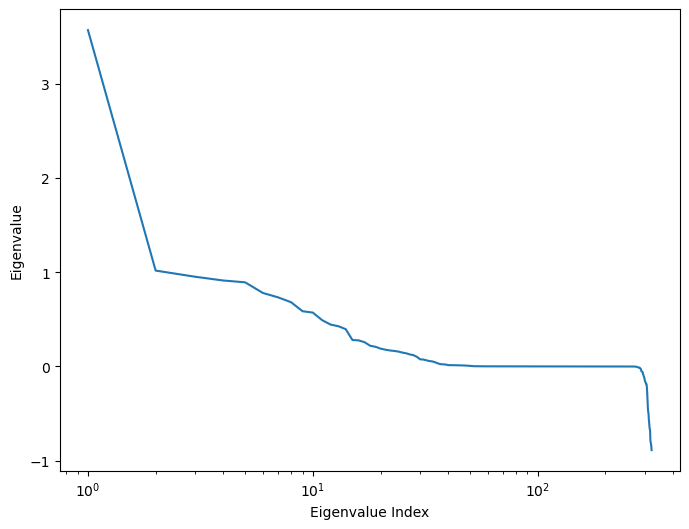

In [13]:
plt.figure(figsize=(8,6))
plt.plot(np.arange(1,len(eigvals)+1),eigvals.numpy()[::-1])
plt.xlabel("Eigenvalue Index")
plt.ylabel("Eigenvalue")
plt.xscale('log')
#plt.yscale('log')

### thing


In [43]:
def make_model():
    return nn.Sequential(
        nn.Linear(1,4,bias=True),
        nn.LeakyReLU(),
        nn.Linear(4,4),
        nn.LeakyReLU(),
        nn.Linear(4,1,bias=True),
    )

In [44]:
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from torch.func import functional_call, hessian

model_init = make_model()
model_init = model_init.to(device)
param_name_shape_sizes = []

for name, param in model_init.named_parameters():
    param_name_shape_sizes.append((name, param.shape, param.numel()))
    print(name)

params_init = parameters_to_vector(model_init.parameters())  # (D,)

def loss_for_hessian(params_flat, X):
    p = {}
    i = 0
    for (name, shape, size) in param_name_shape_sizes:
        p[name] = params_flat[i:i+size].view(shape)
        i += size
    pred = functional_call(model_init, p, X)
    
    loss = pred.sum()
    return loss

x = torch.randn(1,1)
H = hessian(loss_for_hessian)(params_init, x).detach()

0.weight
0.bias
2.weight
2.bias
4.weight
4.bias


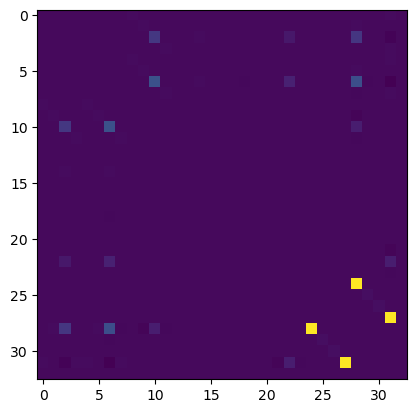

In [45]:
plt.imshow(H)

In [46]:
params_init.shape

torch.Size([33])